# Main for Data Analysis 

Filters analyses and plots track and tour data

This notebook is to be executed after data/data_handling/data-aquisition.ipynb and before main_energy_sim.ipynb

### Imports 

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import seaborn as sns

import data.data_handling.data_visualization as dv
import data.data_handling.data_processing as dp
from data.data_handling.data_processing import colors_fleets, alpha_major, alpha_minor
import data.data_handling.sequential_analysis as sq

## Preprocessing 

### Data filtering
Load and preprocess the raw trips data.

Preprocessing includes, filtering out tracks shorter than 1 km, with avg. speeds > max. speed and with negative durations. Additioally adds forwarder data to each trip.

In [2]:
# Define LOCATIONS
LOCATIONS = dp.LOCATIONS

# Load data
df_trips_unfiltered, df_fleet= dp.load_data()
# Preprocess data
df_trips = dp.preprocess_trips_data(df_trips_unfiltered, df_fleet)

# Fixes tours that 'spill over' into the next tour and cause tracks to be assigned to the wrong track
# This is a problem in the raw data (df_trips_unfiltered)
df_trips = dp.fix_faulty_tour_assignment(df_trips, df_trips_unfiltered)

# Fixes assigns a locations that corresponds to a home base to the end of each tour, if it does not
# do so anyway. Usually because the last track of a tour has been filtered out in preprocess_trips_data()
# If new home bases are addded, update the homebase_map in fix_faulty_tour_endings()
df_trips = dp.fix_faulty_tour_endings(df_trips, df_trips_unfiltered)
#df_trips.to_csv('./input/stations/tracks_filtered.csv')

Found 51 tours with multiple vehicle IDs
Split tour 3066: assigned new tour_id 100000 to vehicle 20
Split tour 5531: assigned new tour_id 200000 to vehicle 29
Split tour 6192: assigned new tour_id 300000 to vehicle 32
Split tour 6662: assigned new tour_id 400000 to vehicle 36
Split tour 6927: assigned new tour_id 500000 to vehicle 40
Split tour 10060: assigned new tour_id 600000 to vehicle 57
Split tour 11508: assigned new tour_id 700000 to vehicle 61
Split tour 12229: assigned new tour_id 800000 to vehicle 63
Split tour 12758: assigned new tour_id 900000 to vehicle 65
Split tour 12859: assigned new tour_id 1000000 to vehicle 70
Split tour 12860: assigned new tour_id 1100000 to vehicle 72
Split tour 12860: assigned new tour_id 1200000 to vehicle 73
Split tour 12874: assigned new tour_id 1300000 to vehicle 74
Split tour 12876: assigned new tour_id 1400000 to vehicle 75
Split tour 12876: assigned new tour_id 1500000 to vehicle 76
Split tour 12876: assigned new tour_id 1600000 to vehicle 

### Process truck occupations and resample dataframes

In [3]:
df_stops = dp.process_stops_data(df_trips)

# Cumulative time spent driving or in each type of location for each truck
df_rt_joined_plot = dp.calculate_rest_times_and_driving(df_stops, df_trips)

# Resample occupation data
# shows time spent (in min) not occurencess
truck_day_occ = dp.resample_occupation_data(df_stops, df_trips)

### Create tour statistics 

Aggregate all tracks that belong to a single tour into a row 

Creates: input/stations/tours.csv

In [4]:
df_tours = dp.aggregate_tours(df_trips, save=True)

# Calculate the percentage of tours with distance_km < 300, < 375, < 500, < 1000
distances = [300, 375, 500, 1000]
percentages = {dist: (df_tours[df_tours['distance_km'] < dist].shape[0] / df_tours.shape[0]) * 100 for dist in distances}

for dist, perc in percentages.items():
    print(f"Tours under {dist} km: {perc:.2f}%")

print('\n')  
# Calculate the percentage of tours with distance_km < 300, < 375, < 500, < 1000 per freight forwarder
ff_percentages = {}
for ff in df_tours['freight_forwarder'].unique():
    ff_data = df_tours[df_tours['freight_forwarder'] == ff]
    ff_percentages[ff] = {dist: (ff_data[ff_data['distance_km'] < dist].shape[0] / ff_data.shape[0]) * 100 for dist in distances}

# Print the results
for ff, stats in ff_percentages.items():
    print(f"Freight Forwarder {ff}:")
    for dist, perc in stats.items():
        print(f"  Tours under {dist} km: {perc:.2f}%")

Tours under 300 km: 82.15%
Tours under 375 km: 86.18%
Tours under 500 km: 89.85%
Tours under 1000 km: 95.32%


Freight Forwarder 1:
  Tours under 300 km: 83.70%
  Tours under 375 km: 85.01%
  Tours under 500 km: 86.85%
  Tours under 1000 km: 95.65%
Freight Forwarder 2:
  Tours under 300 km: 73.44%
  Tours under 375 km: 86.67%
  Tours under 500 km: 99.78%
  Tours under 1000 km: 100.00%
Freight Forwarder 3:
  Tours under 300 km: 92.36%
  Tours under 375 km: 95.27%
  Tours under 500 km: 98.97%
  Tours under 1000 km: 100.00%
Freight Forwarder 4:
  Tours under 300 km: 45.87%
  Tours under 375 km: 48.81%
  Tours under 500 km: 56.60%
  Tours under 1000 km: 80.53%
Freight Forwarder 5:
  Tours under 300 km: 95.58%
  Tours under 375 km: 99.34%
  Tours under 500 km: 99.63%
  Tours under 1000 km: 99.80%
Freight Forwarder 6:
  Tours under 300 km: 57.93%
  Tours under 375 km: 62.93%
  Tours under 500 km: 67.59%
  Tours under 1000 km: 77.24%


### Meta data 

In [5]:
# Calculation of general meta data
meta_data = dp.calculate_meta_data(df_trips_unfiltered, df_trips, df_fleet)
# Converting meta data to DataFrame
general_df, _, _, _ = dp.meta_data_to_df(meta_data)

# Display of DataFrame
display(general_df)

# Converting meta data to DataFrame
_, temporal_df, _, _ = dp.meta_data_to_df(meta_data)

# Display of DataFrame
display(temporal_df)

# Converting meta data to DataFrame
_, _, _, ff_df = dp.meta_data_to_df(meta_data)

# Display of DataFrame
display(ff_df)

,Metric,Value
0,Recorded distance / km,2154292.668
1,Recorded time / h,44385.656
2,Trips,42701
3,Tours,9033
4,Vehicles,163
5,Median vehicle distance / km,7976.07
6,Share of trips shorter than 5h,0.997
7,Trips shorter than 1 km,108412
8,Total recordings,151598
9,Min start time,2021-09-07 09:48:57.981000+00:00


,Metric,Value
0,Average Trips per Day per Truck,284.673
1,Average Trip Duration / h,1.039
2,Average Trip Distance / km,50.451
3,Average Trips per Tour,4.727
4,Average Daily Distance per Truck / km,214.61
5,Average Daily Start Time,06:26:47
6,Average Daily End Time,14:00:48
7,Average Speed per Trip/ km/h,37.761


,Fleet,Vehicles,Recorded distance / 1000 km,Recorded time / h
0,1,18,367118.19,7484.72
1,2,5,136358.72,3139.57
2,3,12,170427.09,5127.28
3,4,18,580956.91,9213.78
4,5,13,341847.05,7314.89
5,6,84,557584.71,12105.41


## Plots

### Data Recordings - Weekly Distance    

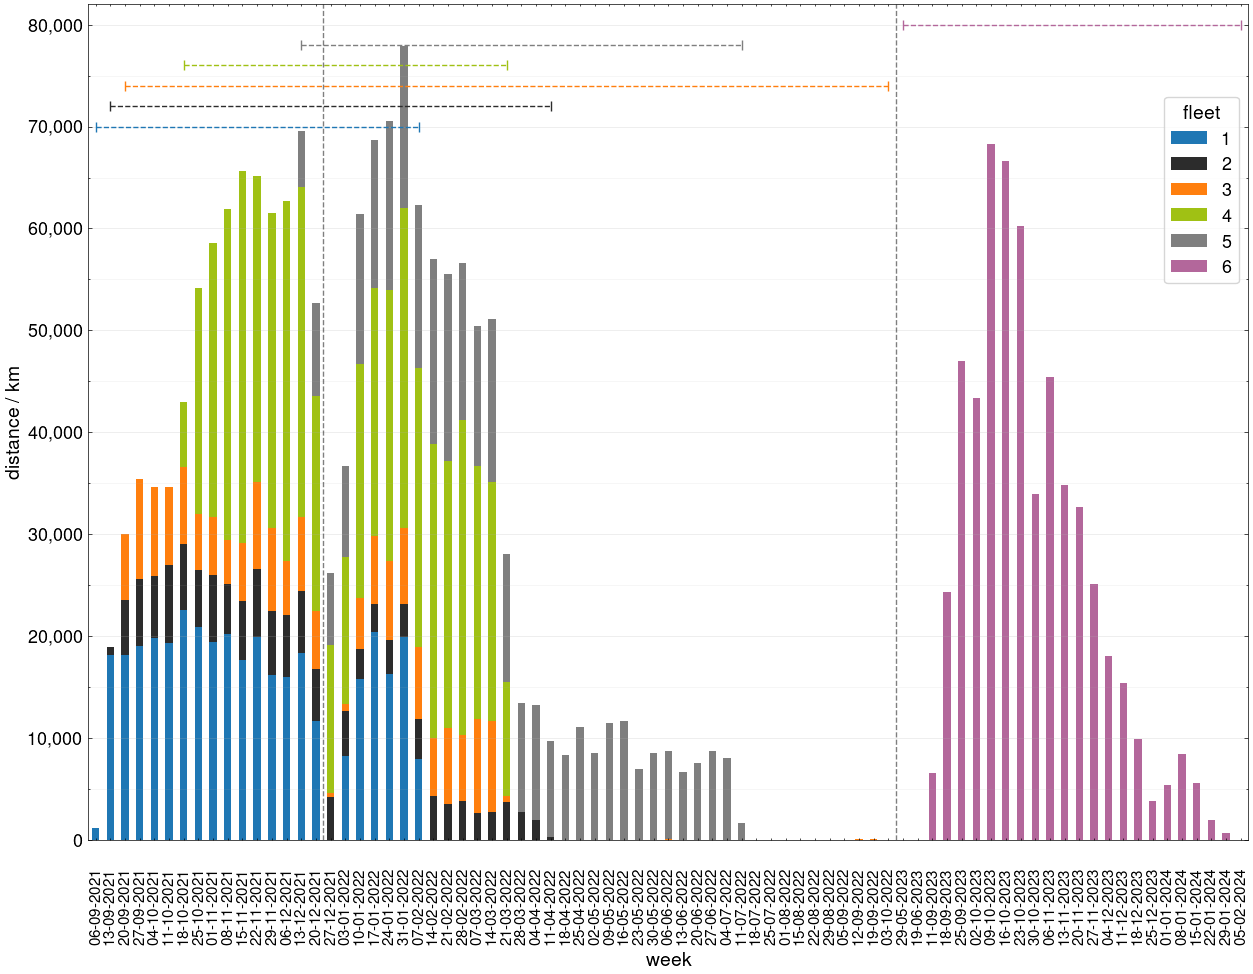

In [6]:
dv.plot_weekly_distances(df_trips)  

### KDE Plots - Tracks - Distance | Duration | Max Speed | Avg Speed

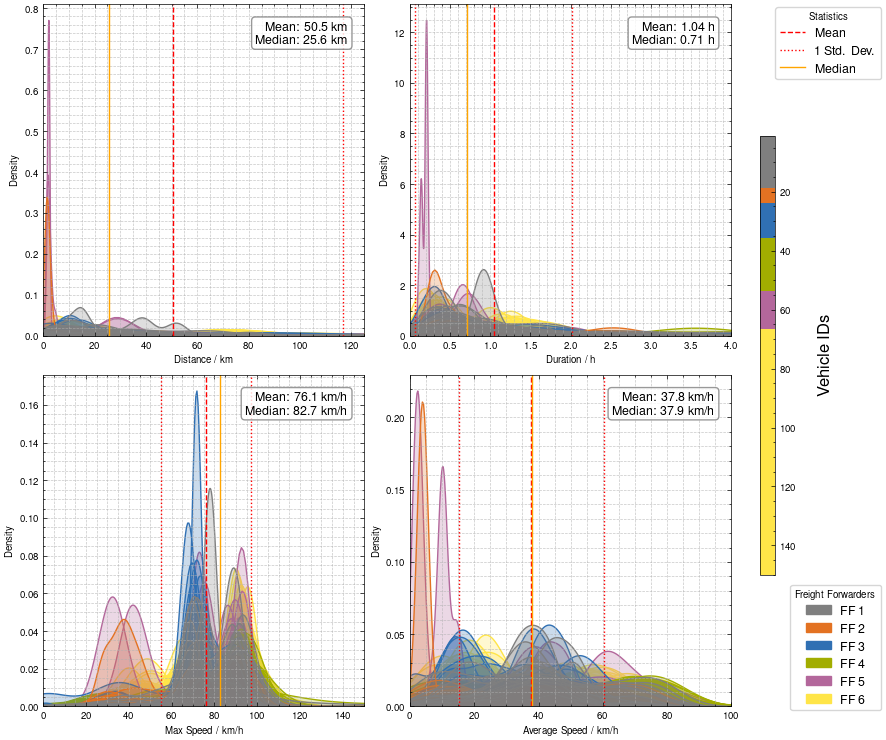

In [7]:
dv.plot_kde_plots(df_trips)

### KDE Plots - Tours - Distance | Duration | Max Speed | Avg Speed

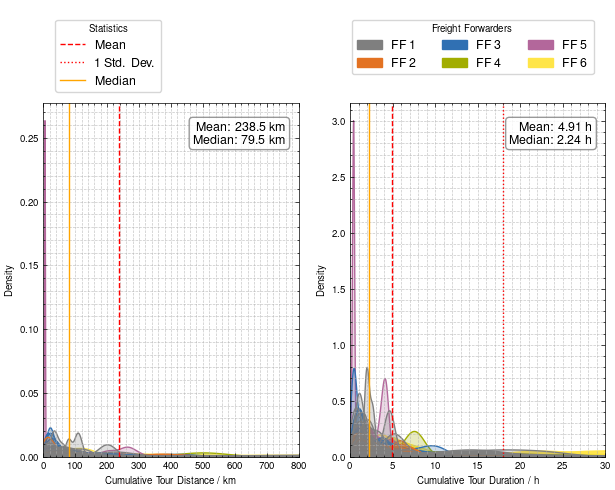

In [8]:
dv.plot_tour_kde_plots(df_trips)

### Weekly Distance Boxplots    


Freight Forwarder 1 - Daily Distance per Truck:
  weekday_name        mean         std    median  count
0       Monday  267.401554  204.375010  218.1335    294
1      Tuesday  259.046242  180.103997  203.9810    310
2    Wednesday  256.429010  191.729833  197.0920    301
3     Thursday  246.578262  181.849164  198.6790    290
4       Friday  188.593383  154.539736  139.6350    277
5     Saturday   96.470931  119.594958   65.8310     29
6       Sunday  135.361909  111.076111  147.7860     33
Overall mean: 239.32 km

Freight Forwarder 2 - Daily Distance per Truck:
  weekday_name        mean         std    median  count
0       Monday  247.686189  174.263176  240.9600    111
1      Tuesday  223.010333  161.732667  244.8725    114
2    Wednesday  249.561393  178.420435  284.5940    117
3     Thursday  230.217590  167.223075  248.7695    122
4       Friday  224.405658  168.915887  226.5210    114
5     Saturday   19.610276   66.720384    4.0720     29
6       Sunday    2.068333    0.535801

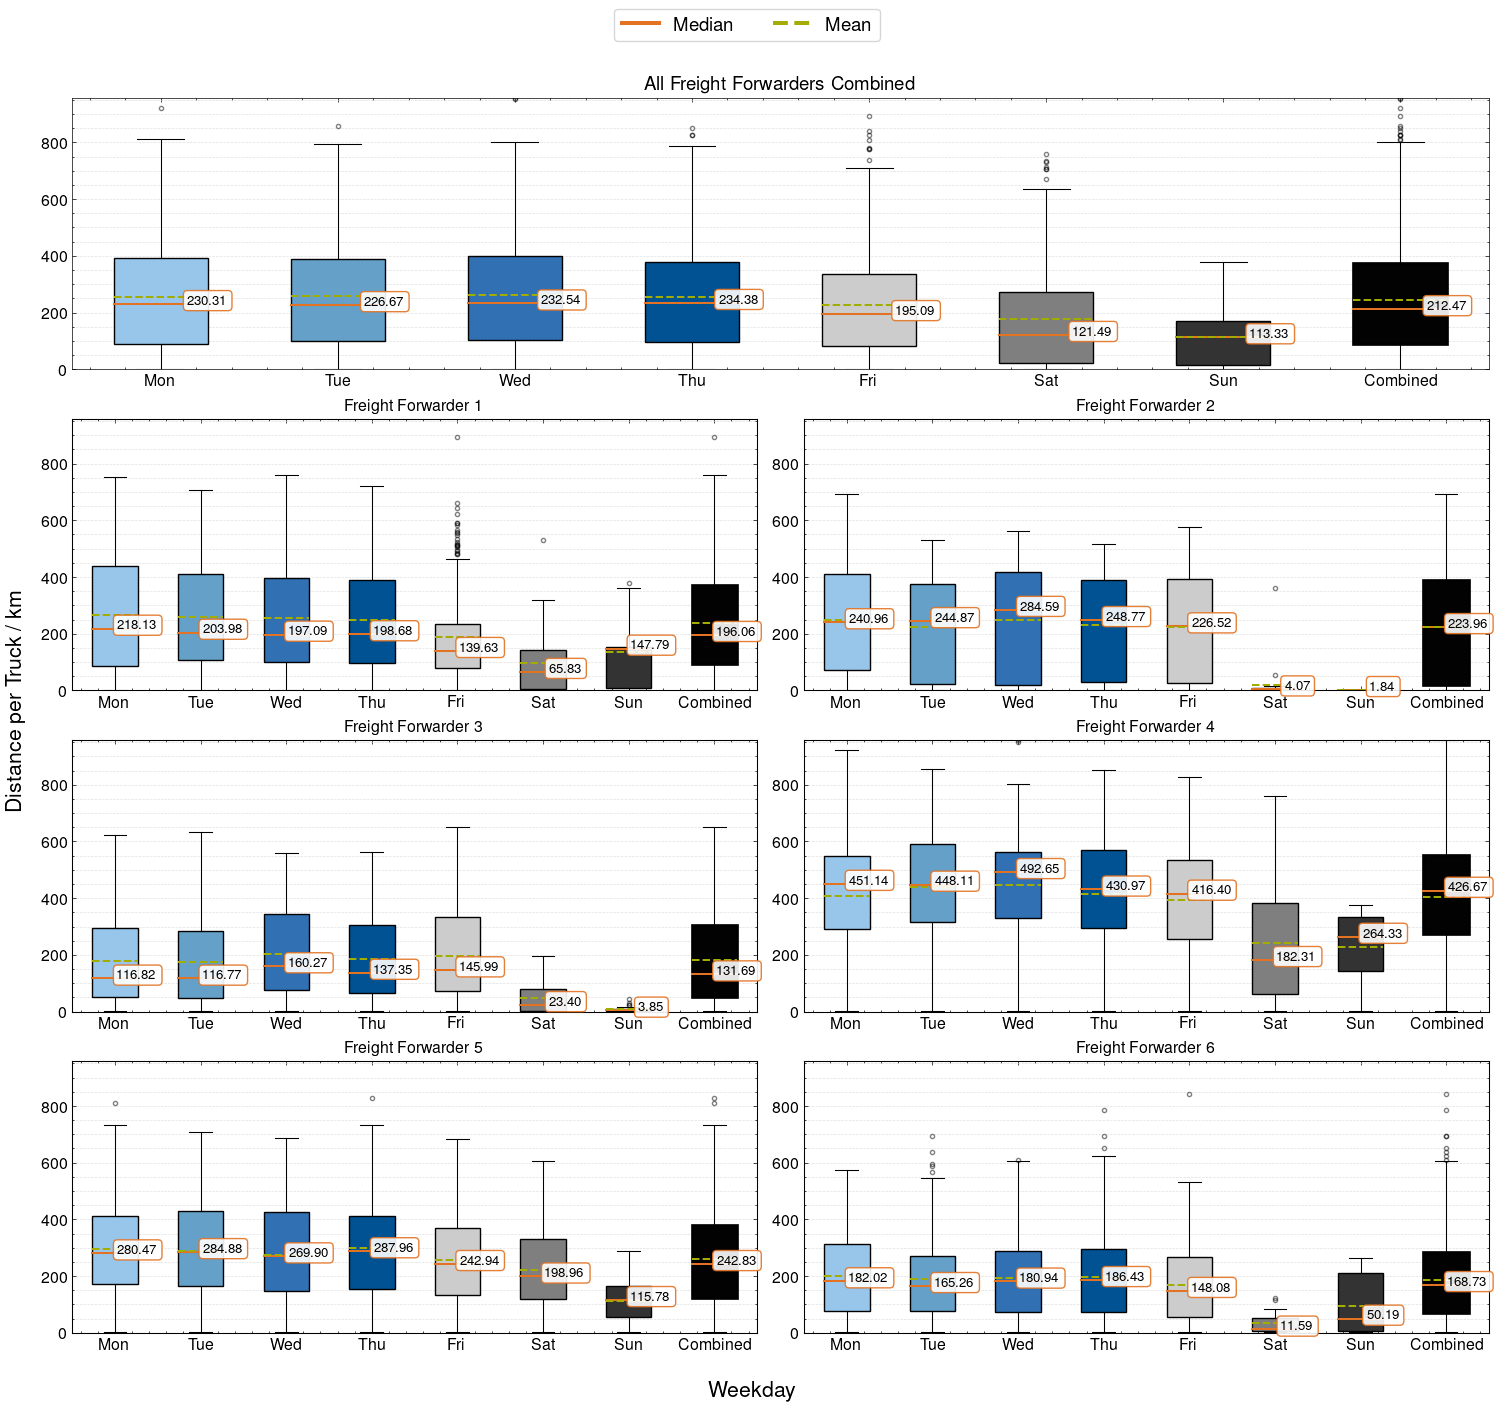

<module 'matplotlib.style' from 'c:\\Users\\ge56wuh\\.anaconda3\\envs\\dt_cargo_electrification\\lib\\site-packages\\matplotlib\\style\\__init__.py'>
Verifying weekday aggregation:
Sample data for Monday:
      vehicle_id        date  weekday  distance_km
407            5  2021-11-22        0       12.865
7204         118  2023-10-16        0       99.504
2162          24  2021-10-25        0      380.849
7194         116  2023-10-23        0      252.413
8052         143  2023-10-16        0      316.306
Sample data for Tuesday:
      vehicle_id        date  weekday  distance_km
6382          83  2023-09-19        1      152.538
8613         159  2023-10-31        1      243.072
8504         156  2024-01-09        1      192.772
7861         137  2023-12-19        1      380.864
5975          72  2023-12-12        1        1.829
Sample data for Wednesday:
      vehicle_id        date  weekday  distance_km
8482         156  2023-11-29        2      245.624
8532         157  2023-10-11 

In [19]:
dv.plot_weekly_distance_boxplot(df_trips)

dv.verify_weekday_aggregation(df_trips)

### Tour Duration and Distance  


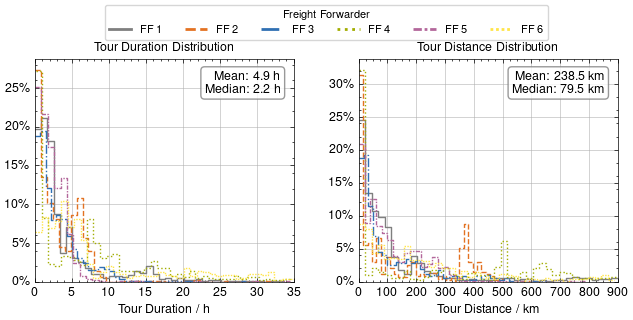

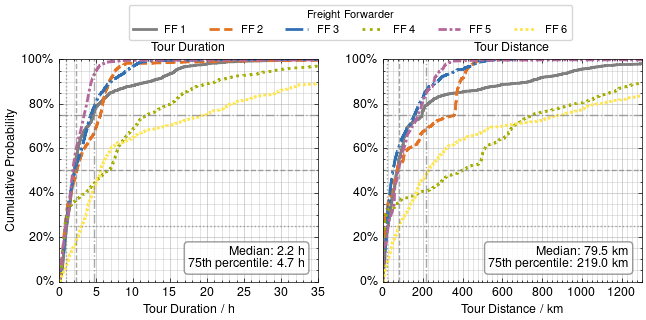

In [18]:
dv.plot_tour_duration_distance_histogram(df_trips, max_distance=900, max_duration=35)
dv.plot_tour_duration_distance_ecdf(df_trips, max_distance=1300, max_duration=35)

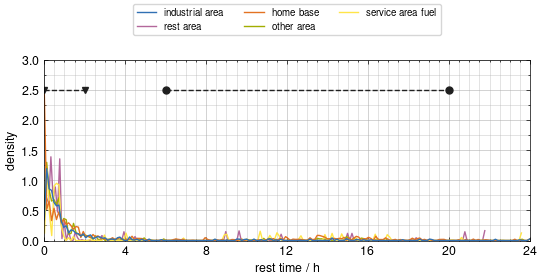

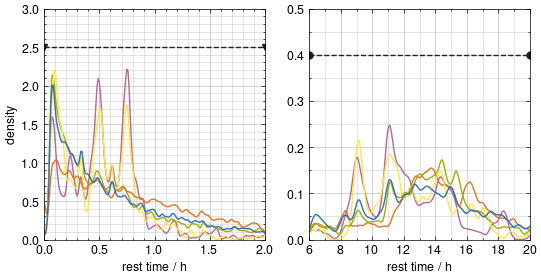

In [11]:
dv.plot_rest_time_kde(df_stops)

## Data Quality
Gaps in recording in relation to recorded distance

In [12]:
total_signal_loss = df_trips['n_signal_loss'].sum()
avg_signal_loss_ratio = df_trips['r_signal_loss'].mean()

print(f'Total signal loss: {total_signal_loss}')
print(f'Average signal loss ratio: {avg_signal_loss_ratio}')

Total signal loss: 95658722.0
Average signal loss ratio: 0.0164873518608612


## Fleet occupation 

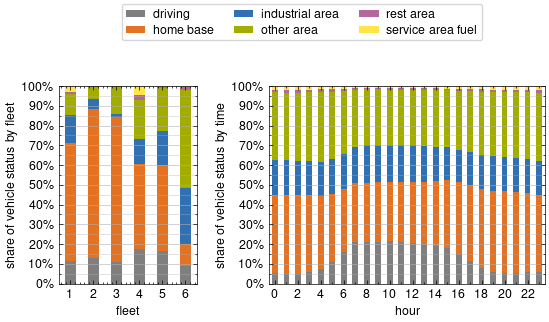

In [13]:
dv.plot_fleet_occupation(df_rt_joined_plot, truck_day_occ)

### Average departure and arrival times

In [14]:
dp.avg_departure_and_arrival()

Freight Forwarder: 1
Average start time: 9h 46min
Average stop time: 12h 43min 

Freight Forwarder: 2
Average start time: 7h 54min
Average stop time: 11h 58min 

Freight Forwarder: 3
Average start time: 10h 4min
Average stop time: 13h 50min 

Freight Forwarder: 4
Average start time: 11h 47min
Average stop time: 13h 55min 

Freight Forwarder: 5
Average start time: 0h 16min
Average stop time: 7h 13min 

Freight Forwarder: 6
Average start time: 9h 43min
Average stop time: 14h 12min 

